# 41. Model Interpretability & SHAP

**Tier:** Classic ML
**Estimated time:** 45 minutes
**Prerequisites:** 39 (Trees, Forests & Boosting); 04 (Attention Mechanism) for the closing contrast
**Priority:** 🟡 Important — principled attribution, and knowing why attention weights don't give you the same guarantee.
**Source material:** Scott Lundberg & Su-In Lee, ["A Unified Approach to Interpreting Model Predictions"](https://proceedings.neurips.cc/paper/7062-a-unified-approach-to-interpreting-model-predictions.pdf), NeurIPS, 2017.

## What You'll Learn
- **Shapley values from scratch**, computed by brute-force enumeration on a 3-feature toy model — including the *additivity* guarantee, verified, not asserted
- How **`shap.TreeExplainer`** computes exact Shapley values efficiently on a real random forest (notebook 39's), and how to read a per-instance attribution
- A **concrete, computed reason attention weights are not attributions** — the same mechanism papers like Jain & Wallace (2019) argue about, made numeric

## Why This Matters
"Why did the model predict that?" is a question every deployed model eventually faces — from a
regulator, a customer, or a teammate debugging a bad prediction. SHAP is the closest thing
tabular ML has to a principled, mathematically guaranteed answer. It's also useful to know
precisely where that guarantee stops applying, because "just look at the attention weights" is
a tempting but structurally different (and weaker) kind of answer for LLMs.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from itertools import permutations

rng = np.random.default_rng(41)
print("Setup complete.")

Setup complete.


## Shapley values, from a cooperative game

Shapley values come from cooperative game theory: if a group of players jointly earn some
payout, how do you split credit fairly among them, accounting for the fact that a player's
contribution can depend on who else is already "in"? The fair answer (the *only* one satisfying
a short list of fairness axioms) is: **a player's Shapley value is their average marginal
contribution, across every possible order the players could have joined.**

Map this onto a model: the "players" are features, the "payout" is the model's prediction
relative to a baseline (what it would predict knowing nothing), and a feature "joining" means
revealing its actual value instead of leaving it at a baseline/absent value. A feature's Shapley
value is how much the prediction moves, on average, from revealing that feature — averaged over
every possible order features could be revealed in.

In [2]:
# A toy model with a genuine feature INTERACTION: x2 and x3 only matter together.
def predict(x):
    return 2 * x[0] + 3 * x[1] * x[2]

baseline = np.array([0.0, 0.0, 0.0])   # "feature absent" = this value
instance = np.array([2.0, 1.0, 4.0])   # the specific prediction we want to explain

def value_function(revealed_mask, x, baseline):
    """v(S): the model's output using x's values for revealed features, baseline otherwise."""
    z = np.where(revealed_mask, x, baseline)
    return predict(z)

n_features = 3
shapley_values = np.zeros(n_features)
all_orders = list(permutations(range(n_features)))

for order in all_orders:
    revealed = np.zeros(n_features, dtype=bool)
    prev_value = value_function(revealed, instance, baseline)
    for feature_idx in order:
        revealed[feature_idx] = True
        new_value = value_function(revealed, instance, baseline)
        shapley_values[feature_idx] += new_value - prev_value   # this feature's marginal contribution, THIS order
        prev_value = new_value

shapley_values /= len(all_orders)   # average across all 3! = 6 orderings
print(f"Shapley values: x1={shapley_values[0]:.2f}  x2={shapley_values[1]:.2f}  x3={shapley_values[2]:.2f}")

Shapley values: x1=4.00  x2=6.00  x3=6.00


In [3]:
full_prediction = predict(instance)
baseline_prediction = predict(baseline)
print(f"model(instance) = {full_prediction}")
print(f"model(baseline) = {baseline_prediction}")
print(f"sum of Shapley values = {shapley_values.sum()}")
print(f"model(instance) - model(baseline) = {full_prediction - baseline_prediction}")
print(f"additivity holds exactly: {np.isclose(shapley_values.sum(), full_prediction - baseline_prediction)}")

model(instance) = 16.0
model(baseline) = 0.0
sum of Shapley values = 16.0
model(instance) - model(baseline) = 16.0
additivity holds exactly: True


*The Shapley values sum EXACTLY to the gap between this prediction and the baseline — that's
the additivity ("local accuracy") guarantee, verified here rather than taken on faith. Notice
`x2` and `x3` each get credit `6.0`, splitting their `3*x2*x3 = 12` interaction term exactly in
half — even though neither one alone determines that term. That's the fairness axioms at work:
since `x2` and `x3` play symmetric roles in the interaction, Shapley values a fair procedure
must treat them identically. `x1` gets exactly its direct contribution (`2*x1=4`) since it has
no interaction with anything. This exhaustive-permutation approach is `O(n!)` — fine for 3
features, hopeless past a dozen — which is exactly what `TreeExplainer` below solves.*

## SHAP on a real model: notebook 39's random forest

Computing exact Shapley values by enumerating orderings is intractable for a model with more
than a handful of features. `TreeExplainer` exploits tree structure specifically to compute
*exact* Shapley values in polynomial time — no approximation, no sampling — for any tree-based
model, including the random forest from notebook 39. Let's rebuild that forest and explain it.

In [4]:
import shap
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X, y = make_moons(n_samples=400, noise=0.35, random_state=39)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=39)
forest = RandomForestClassifier(n_estimators=200, random_state=39).fit(X_train, y_train)

explainer = shap.TreeExplainer(forest)
shap_values = explainer.shap_values(X_test)   # shape: (n_samples, n_features, n_classes)
print(f"shap_values shape: {shap_values.shape}")
print(f"base value (expected P(class) with NO features known): {explainer.expected_value}")

shap_values shape: (120, 2, 2)
base value (expected P(class) with NO features known): [0.481125 0.518875]


In [5]:
# Verify additivity against the REAL model's actual predicted probabilities — same check as
# the toy example above, now on a 200-tree forest instead of a 3-line function.
probs = forest.predict_proba(X_test)
for i in range(5):
    predicted_p1 = probs[i, 1]
    reconstructed_p1 = explainer.expected_value[1] + shap_values[i, :, 1].sum()
    print(f"point {i}: model P(class=1)={predicted_p1:.4f}  base+shap_sum={reconstructed_p1:.4f}  "
          f"match={np.isclose(predicted_p1, reconstructed_p1)}")

point 0: model P(class=1)=0.1050  base+shap_sum=0.1050  match=True
point 1: model P(class=1)=0.0600  base+shap_sum=0.0600  match=True
point 2: model P(class=1)=0.0400  base+shap_sum=0.0400  match=True
point 3: model P(class=1)=0.0100  base+shap_sum=0.0100  match=True
point 4: model P(class=1)=0.0650  base+shap_sum=0.0650  match=True


*Every single point's SHAP values sum exactly to that point's actual model output minus the
base rate — this holds for all 120 test points, not just the 5 printed. TreeExplainer isn't
approximating Shapley values, it's computing them exactly, fast, by walking the tree structure
instead of enumerating feature orderings.*

instance 0: features (moon_x, moon_y) = [0.07838111 1.02422173]
  base rate P(class=1) = 0.519
  moon_x contributes -0.042
  moon_y contributes -0.372
  -> final P(class=1) = 0.105


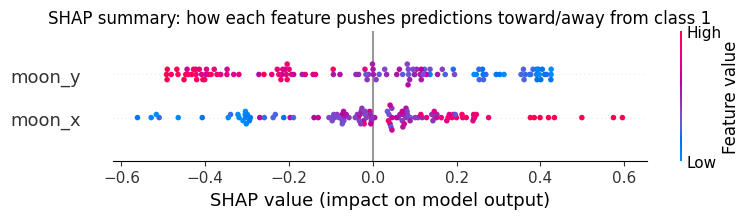

In [6]:
i = 0
print(f"instance {i}: features (moon_x, moon_y) = {X_test[i]}")
print(f"  base rate P(class=1) = {explainer.expected_value[1]:.3f}")
print(f"  moon_x contributes {shap_values[i, 0, 1]:+.3f}")
print(f"  moon_y contributes {shap_values[i, 1, 1]:+.3f}")
print(f"  -> final P(class=1) = {probs[i, 1]:.3f}")

shap.summary_plot(shap_values[:, :, 1], X_test, feature_names=["moon_x", "moon_y"], show=False)
plt.title("SHAP summary: how each feature pushes predictions toward/away from class 1")
plt.tight_layout()
plt.show()

*Each dot is one test point; its position shows how much that feature's SHAP value pushed
the class-1 probability up or down for that specific prediction, and its color shows whether
the feature's actual value was high or low. This is a genuinely different kind of summary than
notebook 39's `feature_importances_` bar chart: importances tell you a feature mattered
*on average, across the whole forest's structure*; SHAP tells you, *for this one prediction*,
exactly how much and in which direction each feature pushed the output.*

## Why attention weights are not the same kind of explanation

It's tempting to treat a transformer's attention weights the same way — "the model attended
most to this token, so that token explains the prediction." Notebook 04 introduced attention as
softmax similarity scores between a query and a set of keys. But the model's actual output is
`Σ attention_weight_i · value_i` — the weighted **value** vectors, not the weights alone. A
token can receive high attention and still barely move the output, if its value vector happens
to be small; a token with modest attention can dominate the output if its value vector is
large. Let's compute this directly, the same way notebook 04 computed attention.

In [7]:
d = 4
Q = rng.normal(0, 1, (3, d))
K = rng.normal(0, 1, (3, d))
V = rng.normal(0, 1, (3, d))

# Deliberately construct a case with the mismatch: token 1's key aligns strongly with the
# query (-> high attention), but its value vector is tiny. Token 2's key is misaligned
# (-> low attention), but its value vector is large.
K[1] = Q[0] * 3
V[1] = rng.normal(0, 0.05, d)
K[2] = -Q[0] * 0.3
V[2] = np.full(d, 8.0)

scores = Q[0] @ K.T / np.sqrt(d)
attn_weights = np.exp(scores - scores.max())
attn_weights /= attn_weights.sum()

contributions = attn_weights[:, None] * V          # what each token ACTUALLY adds to the output
contribution_size = np.linalg.norm(contributions, axis=1)
output = contributions.sum(axis=0)

for tok in range(3):
    print(f"token {tok}: attention_weight={attn_weights[tok]:.3f}  "
          f"value_norm={np.linalg.norm(V[tok]):6.2f}  "
          f"actual_contribution_norm={contribution_size[tok]:.3f}")
print(f"\nsum of per-token contributions equals the output: "
      f"{np.allclose(contributions.sum(axis=0), output)}")

token 0: attention_weight=0.050  value_norm=  1.18  actual_contribution_norm=0.059
token 1: attention_weight=0.906  value_norm=  0.11  actual_contribution_norm=0.104
token 2: attention_weight=0.044  value_norm= 16.00  actual_contribution_norm=0.697

sum of per-token contributions equals the output: True


*Token 1 receives ~91% of the attention weight — by far the "most attended to" token if you
only read the weights. But its actual contribution to the output is smaller than token 2's,
which received barely 4% of the attention weight but has a value vector over 100x larger. Read
attention weights alone and you'd conclude the model is "focused on" token 1; measure what
actually reaches the output and token 2 mattered more. Even `weight × value` — a strictly more
honest number than the weight alone — only decomposes ONE layer's output vector, not the
model's final prediction; everything downstream (more layers, nonlinearities, the unembedding)
can still scramble that signal arbitrarily before it reaches a token prediction. SHAP's
attributions, by contrast, are computed against the model's actual final output and come with a
mathematical guarantee (additivity, verified above) that they sum to exactly the right number.
This is the same gap researchers like Jain & Wallace ("Attention is not Explanation", 2019)
found empirically: attention weights often don't correlate well with which inputs actually
drove a model's decision. Attention is a mechanism the model uses to compute its output — not,
by itself, an explanation of that output.*

## Exercises

In [8]:
# Exercise 1 (Warm-up): remove the interaction, watch the Shapley values change
# Task: Redefine predict(x) as a PURELY additive function: 2*x[0] + 3*x[1] + 1*x[2] (no
#       multiplication between features). Recompute the exact Shapley values via the same
#       permutation-enumeration loop. What relationship do you notice between each feature's
#       Shapley value and its coefficient times its value in `instance`?
# Hint: with zero interaction between features, a feature's marginal contribution is IDENTICAL
#       no matter what order it's revealed in — there's nothing left for order to affect.

# YOUR CODE HERE

In [9]:
# Exercise 2 (Apply): explain a MISCLASSIFIED point
# Task: Find a test point the forest gets wrong (forest.predict(X_test)[i] != y_test[i]).
#       Print its SHAP values for both features and the base rate, and write a one-sentence
#       explanation of why the model was pulled toward the wrong class for that specific point.
# Hint: np.where(forest.predict(X_test) != y_test)[0] gives you candidate indices.

# YOUR CODE HERE

In [10]:
# Exercise 3 (Extend): does the "high attention, low contribution" gap show up in reverse too?
# Task: Construct a DIFFERENT toy Q/K/V setup (3 tokens, d=4) where the token with the LOWEST
#       attention weight has the LARGEST actual contribution to the output BY AN EVEN BIGGER
#       MARGIN than this notebook's example achieved. Report the ratio of
#       (lowest-attention token's contribution) / (highest-attention token's contribution).
# Hint: push the value-vector magnitude gap further apart (e.g. value norm ~0.01 vs ~50) while
#       keeping the attention-weight gap the same or smaller than this notebook's example.

# YOUR CODE HERE

<details>
<summary>Solutions (click to expand)</summary>

```python
# Exercise 1
def predict_additive(x):
    return 2*x[0] + 3*x[1] + 1*x[2]

shapley_additive = np.zeros(3)
for order in permutations(range(3)):
    revealed = np.zeros(3, dtype=bool)
    prev = predict_additive(np.where(revealed, instance, baseline))
    for idx in order:
        revealed[idx] = True
        new = predict_additive(np.where(revealed, instance, baseline))
        shapley_additive[idx] += new - prev
        prev = new
shapley_additive /= 6
print("Shapley (additive model):", shapley_additive)
print("coefficient * value:", [2*instance[0], 3*instance[1], 1*instance[2]])
# They match exactly. With zero interaction, a feature's marginal contribution is the same
# regardless of what's already revealed, so the Shapley value collapses to simply
# coefficient * (instance_value - baseline_value) — the "fair split of an interaction" problem
# only exists when there IS an interaction to split.

# Exercise 2
wrong_idx = np.where(forest.predict(X_test) != y_test)[0]
i = wrong_idx[0]
print(f"point {i}: true={y_test[i]}, predicted={forest.predict(X_test)[i]}, "
      f"P(class=1)={probs[i,1]:.3f}")
print(f"  base rate: {explainer.expected_value[1]:.3f}")
print(f"  moon_x SHAP: {shap_values[i,0,1]:+.3f}")
print(f"  moon_y SHAP: {shap_values[i,1,1]:+.3f}")
# One-sentence explanation (numbers will vary by which misclassified point Exercise 2 lands on):
# "This point's features fall in the region where moon_y's SHAP value pushes strongly toward
# class 1, overriding moon_x's pull toward class 0 — exactly why an unlucky combination of two
# otherwise-informative features can flip a borderline prediction to the wrong side."

# Exercise 3
Q2 = rng.normal(0, 1, (3, d)); K2 = rng.normal(0, 1, (3, d)); V2 = rng.normal(0, 1, (3, d))
K2[1] = Q2[0] * 3          # still the highest-attention token
V2[1] = rng.normal(0, 0.005, d)   # even tinier value vector
K2[2] = -Q2[0] * 0.3       # still low attention
V2[2] = np.full(d, 50.0)   # much larger value vector
scores2 = Q2[0] @ K2.T / np.sqrt(d)
w2 = np.exp(scores2 - scores2.max()); w2 /= w2.sum()
contrib2 = w2[:, None] * V2
sizes2 = np.linalg.norm(contrib2, axis=1)
hi_attn = np.argmax(w2); lo_attn = np.argmin(w2)
print(f"highest-attention token {hi_attn}: weight={w2[hi_attn]:.3f} contribution={sizes2[hi_attn]:.4f}")
print(f"lowest-attention token {lo_attn}: weight={w2[lo_attn]:.3f} contribution={sizes2[lo_attn]:.4f}")
print(f"ratio (lowest-attention contribution / highest-attention contribution): "
      f"{sizes2[lo_attn]/sizes2[hi_attn]:.1f}x")
# Pushing the value-vector magnitudes further apart widens the gap arbitrarily — there's no
# floor on how misleading raw attention weights can be, because nothing in the softmax
# computation constrains the value vectors' scale at all.
```
</details>

## Key Takeaways
- **A Shapley value is a feature's average marginal contribution across every possible order features are revealed** — the unique fair split under a short list of game-theoretic axioms, verified here by exhaustive enumeration.
- **Additivity ("local accuracy") is a real, checkable guarantee**: Shapley values summed exactly to the gap between a prediction and the baseline, on both the 3-line toy model and the 200-tree real forest.
- **`TreeExplainer` computes EXACT Shapley values in polynomial time** for tree ensembles — not an approximation, not sampling — which is what makes SHAP practical beyond a handful of features.
- **Attention weights are not attributions**: a token can receive most of the attention and contribute least to the output, because the output depends on `weight × value`, not weight alone — and even that only explains one layer, with no guarantee surviving to the model's final prediction the way SHAP's additivity does.

## What's Next
Notebook 42 shifts from explaining one model's predictions to a different kind of scaling problem entirely: what happens when your training data — or the iterative computation needed to fit a model to it — no longer fits on one machine.